# SupportSense — Model Comparison and Selection

This notebook compares the machine-learning approaches developed for
the BANKING77 customer-support intent classification problem.

The evaluated approaches are:

1. TF-IDF + Linear SVM using scikit-learn
2. Embedding-based neural classifier using PyTorch
3. Embedding-based neural classifier using TensorFlow/Keras

The objective is to select a production candidate using measured
performance and engineering trade-offs rather than model complexity
alone.

The comparison considers:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Per-class performance
- Error patterns
- Model artifact size
- Training complexity
- Inference complexity
- Maintainability

In [4]:
# Imports
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
PROJECT_ROOT = Path("..").resolve()

REPORTS_DIR = (
    PROJECT_ROOT / "reports"
)

MODELS_DIR = (
    PROJECT_ROOT / "models"
)

In [6]:
# Load the three official test results
svm_results = pd.read_csv(
    REPORTS_DIR
    / "final_test_metrics.csv"
)

pytorch_results = pd.read_csv(
    REPORTS_DIR
    / "pytorch_test_metrics.csv"
)

tensorflow_results = pd.read_csv(
    REPORTS_DIR
    / "tensorflow_test_metrics.csv"
)

## Inspecting each one

In [7]:
# SVM results
svm_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Linear SVM,0.893182,0.896669,0.893182,0.893366


In [8]:
# PyTorch results
pytorch_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,PyTorch Embedding Classifier,0.833117,0.841465,0.833117,0.833511


In [9]:
# TensorFlow results
tensorflow_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TensorFlow Embedding Classifier,0.878571,0.882483,0.878571,0.878492


In [10]:
# Checking column names
print(
    "SVM:",
    svm_results.columns.tolist()
)

print(
    "PyTorch:",
    pytorch_results.columns.tolist()
)

print(
    "TensorFlow:",
    tensorflow_results.columns.tolist()
)

SVM: ['Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
PyTorch: ['Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
TensorFlow: ['Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']


In [11]:
# Combine the results
model_comparison = pd.concat(
    [
        svm_results,
        pytorch_results,
        tensorflow_results,
    ],
    ignore_index=True,
)

In [12]:
model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Linear SVM,0.8932,0.8967,0.8932,0.8934
1,PyTorch Embedding Classifier,0.8331,0.8415,0.8331,0.8335
2,TensorFlow Embedding Classifier,0.8786,0.8825,0.8786,0.8785


### Ranking by Macro F1
For this multiclass problem, Macro F1 is made the primary model-selection metric because it gives equal importance to each intent class rather than allowing larger classes to dominate the score.

In [13]:
model_ranking = (
    model_comparison
    .sort_values(
        by="Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

model_ranking.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Linear SVM,0.8932,0.8967,0.8932,0.8934
1,TensorFlow Embedding Classifier,0.8786,0.8825,0.8786,0.8785
2,PyTorch Embedding Classifier,0.8331,0.8415,0.8331,0.8335


In [14]:
best_model_name = (
    model_ranking.iloc[0][
        "Model"
    ]
)

best_macro_f1 = (
    model_ranking.iloc[0][
        "Macro F1"
    ]
)

print(
    "Highest Macro F1:",
    best_model_name
)

print(
    f"Macro F1: "
    f"{best_macro_f1:.4f}"
)

Highest Macro F1: TF-IDF + Linear SVM
Macro F1: 0.8934


In [15]:
# Calculate the gap between models
best_f1 = (
    model_ranking.iloc[0][
        "Macro F1"
    ]
)

second_f1 = (
    model_ranking.iloc[1][
        "Macro F1"
    ]
)

third_f1 = (
    model_ranking.iloc[2][
        "Macro F1"
    ]
)

print(
    f"Best vs second: "
    f"{best_f1 - second_f1:.4f}"
)

print(
    f"Best vs third: "
    f"{best_f1 - third_f1:.4f}"
)

Best vs second: 0.0149
Best vs third: 0.0599


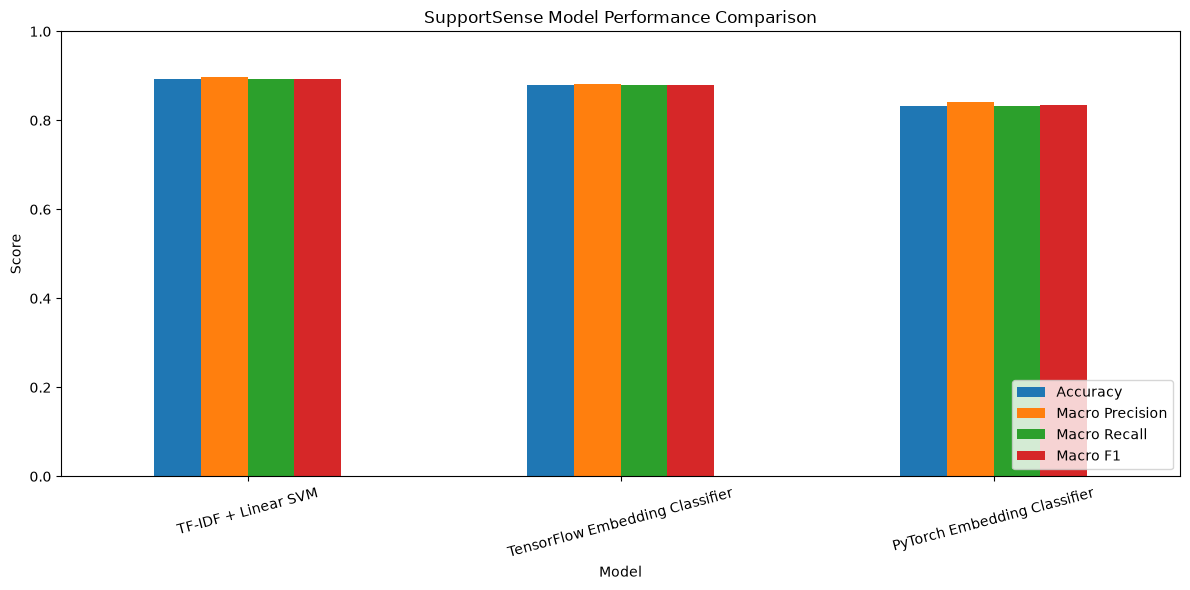

In [46]:
# Plot the comparison

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

plot_data = (
    model_ranking
    .set_index("Model")[
        [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
        ]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title(
    "SupportSense Model Performance Comparison"
)

plt.ylabel("Score")

plt.ylim(
    0,
    1,
)

plt.xticks(
    rotation=15,
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()


plt.savefig(
    FIGURES_DIR
    / "model_performance_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [17]:
# Save the final comparison
model_ranking.to_csv(
    REPORTS_DIR
    / "final_model_comparison.csv",
    index=False,
)

print(
    "Saved final_model_comparison.csv"
)

Saved final_model_comparison.csv


### Compare errors
Raw aggregate scores aren't enough.
There is need to know whether the models fail in similar ways

In [18]:
# Load prediction files
svm_predictions = pd.read_csv(
    REPORTS_DIR
    / "test_predictions.csv"
)

pytorch_predictions = pd.read_csv(
    REPORTS_DIR
    / "pytorch_test_predictions.csv"
)

tensorflow_predictions = pd.read_csv(
    REPORTS_DIR
    / "tensorflow_test_predictions.csv"
)

## Inspect

In [19]:
# SVM predictions
svm_predictions.head()

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
1,"I still have not received my new card, I order...",card_arrival,card_arrival,True
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient,False
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,True
4,My card has not arrived yet.,card_arrival,card_arrival,True


In [20]:
# PyTorch predictions
pytorch_predictions.head()

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
1,"I still have not received my new card, I order...",card_arrival,card_arrival,True
2,I ordered a card but it has not arrived. Help ...,card_arrival,card_arrival,True
3,Is there a way to know when my card will arrive?,card_arrival,card_delivery_estimate,False
4,My card has not arrived yet.,card_arrival,card_arrival,True


In [21]:
# TensorFlow predictions
tensorflow_predictions.head()

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
1,"I still have not received my new card, I order...",card_arrival,card_arrival,True
2,I ordered a card but it has not arrived. Help ...,card_arrival,card_arrival,True
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,True
4,My card has not arrived yet.,card_arrival,card_arrival,True


## Each should contain enough information to identify:
text
actual
predicted

In [22]:
# Verify alignment before comparing rows
print(
    len(svm_predictions)
)

print(
    len(pytorch_predictions)
)

print(
    len(tensorflow_predictions)
)

3080
3080
3080


In [23]:
# Verify that the text order is identical:
svm_pytorch_text_match = (
    svm_predictions["text"]
    .reset_index(drop=True)
    .equals(
        pytorch_predictions["text"]
        .reset_index(drop=True)
    )
)

svm_tensorflow_text_match = (
    svm_predictions["text"]
    .reset_index(drop=True)
    .equals(
        tensorflow_predictions["text"]
        .reset_index(drop=True)
    )
)

print(
    "SVM/PyTorch aligned:",
    svm_pytorch_text_match
)

print(
    "SVM/TensorFlow aligned:",
    svm_tensorflow_text_match
)

SVM/PyTorch aligned: True
SVM/TensorFlow aligned: True


In [24]:
# Building one combined prediction table
comparison_predictions = pd.DataFrame({
    "text":
        svm_predictions["text"],

    "actual":
        svm_predictions["actual"],

    "svm_prediction":
        svm_predictions["predicted"],

    "pytorch_prediction":
        pytorch_predictions["predicted"],

    "tensorflow_prediction":
        tensorflow_predictions["predicted"],
})

In [25]:
comparison_predictions.head()

,text,actual,svm_prediction,pytorch_prediction,tensorflow_prediction
0,How do I locate my card?,card_arrival,get_physical_card,get_physical_card,get_physical_card
1,"I still have not received my new card, I order...",card_arrival,card_arrival,card_arrival,card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient,card_arrival,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,card_delivery_estimate,card_arrival
4,My card has not arrived yet.,card_arrival,card_arrival,card_arrival,card_arrival


In [26]:
# Adding correctness columns
comparison_predictions[
    "svm_correct"
] = (
    comparison_predictions[
        "svm_prediction"
    ]
    ==
    comparison_predictions[
        "actual"
    ]
)

comparison_predictions[
    "pytorch_correct"
] = (
    comparison_predictions[
        "pytorch_prediction"
    ]
    ==
    comparison_predictions[
        "actual"
    ]
)

comparison_predictions[
    "tensorflow_correct"
] = (
    comparison_predictions[
        "tensorflow_prediction"
    ]
    ==
    comparison_predictions[
        "actual"
    ]
)

In [27]:
# Count correct predictions
correct_counts = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "PyTorch",
        "TensorFlow",
    ],

    "Correct Predictions": [
        comparison_predictions[
            "svm_correct"
        ].sum(),

        comparison_predictions[
            "pytorch_correct"
        ].sum(),

        comparison_predictions[
            "tensorflow_correct"
        ].sum(),
    ],
})

correct_counts

,Model,Correct Predictions
0,Linear SVM,2751
1,PyTorch,2566
2,TensorFlow,2706


In [28]:
# Find examples all three get wrong
all_wrong = (
    comparison_predictions[
        (
            ~comparison_predictions[
                "svm_correct"
            ]
        )
        &
        (
            ~comparison_predictions[
                "pytorch_correct"
            ]
        )
        &
        (
            ~comparison_predictions[
                "tensorflow_correct"
            ]
        )
    ]
)

In [29]:
print(
    "Examples all models got wrong:",
    len(all_wrong)
)

Examples all models got wrong: 182


In [30]:
# Inspect
all_wrong.head(20)

,text,actual,svm_prediction,pytorch_prediction,tensorflow_prediction,svm_correct,pytorch_correct,tensorflow_correct
0,How do I locate my card?,card_arrival,get_physical_card,get_physical_card,get_physical_card,False,False,False
5,When will I get my card?,card_arrival,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate,False,False,False
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate,False,False,False
93,Is it a good time to exchange?,exchange_rate,exchange_charge,cancel_transfer,transfer_not_received_by_recipient,False,False,False
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,card_payment_fee_charged,cash_withdrawal_charge,card_payment_fee_charged,False,False,False
150,the conversion value for my card payments is i...,card_payment_wrong_exchange_rate,reverted_card_payment?,card_arrival,reverted_card_payment?,False,False,False
156,How can I check the exchange rate applied to m...,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal,wrong_exchange_rate_for_cash_withdrawal,exchange_rate,False,False,False
164,There is a fee I don't recognize on my statement.,extra_charge_on_statement,card_payment_not_recognised,card_payment_not_recognised,card_payment_not_recognised,False,False,False
172,When will the $1 transaction be credited to me?,extra_charge_on_statement,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient,False,False,False
173,Where did this fee come from?,extra_charge_on_statement,transfer_fee_charged,verify_source_of_funds,card_payment_fee_charged,False,False,False


## Reading some of these messages, it can be noticed that these are potentially intrinsically difficult/ambiguous cases.

In [31]:
# Find cases only SVM gets right
svm_only_correct = (
    comparison_predictions[
        (
            comparison_predictions[
                "svm_correct"
            ]
        )
        &
        (
            ~comparison_predictions[
                "pytorch_correct"
            ]
        )
        &
        (
            ~comparison_predictions[
                "tensorflow_correct"
            ]
        )
    ]
)

In [32]:
print(
    "Only SVM correct:",
    len(svm_only_correct)
)

Only SVM correct: 142


In [33]:
# Inspect
svm_only_correct.head(20)

,text,actual,svm_prediction,pytorch_prediction,tensorflow_prediction,svm_correct,pytorch_correct,tensorflow_correct
32,How do I know when my card will arrive?,card_arrival,card_arrival,card_delivery_estimate,card_delivery_estimate,True,False,False
240,"If I request that my funds be held, what curre...",fiat_currency_support,fiat_currency_support,supported_cards_and_currencies,supported_cards_and_currencies,True,False,False
255,How do I change currencies to euros?,fiat_currency_support,fiat_currency_support,exchange_via_app,exchange_via_app,True,False,False
275,Besides USD what other currencies can I have?,fiat_currency_support,fiat_currency_support,exchange_via_app,exchange_via_app,True,False,False
293,What is the difference between standard and ex...,card_delivery_estimate,card_delivery_estimate,supported_cards_and_currencies,supported_cards_and_currencies,True,False,False
300,How fast can you deliver?,card_delivery_estimate,card_delivery_estimate,fiat_currency_support,fiat_currency_support,True,False,False
331,"I just activated auto top-up, but it is not le...",automatic_top_up,automatic_top_up,top_up_failed,top_up_failed,True,False,False
339,How do I make sure I don't run out of money on...,automatic_top_up,automatic_top_up,card_payment_not_recognised,card_payment_not_recognised,True,False,False
340,What's the limit on automatic top-up?,automatic_top_up,automatic_top_up,top_up_limits,top_up_limits,True,False,False
349,I've tried looking for the auto-top up option ...,automatic_top_up,automatic_top_up,top_up_failed,top_up_failed,True,False,False


In [34]:
# Find cases only PyTorch gets 
pytorch_only_correct = (
    comparison_predictions[
        (
            ~comparison_predictions[
                "svm_correct"
            ]
        )
        &
        (
            comparison_predictions[
                "pytorch_correct"
            ]
        )
        &
        (
            ~comparison_predictions[
                "tensorflow_correct"
            ]
        )
    ]
)

print(
    "Only PyTorch correct:",
    len(pytorch_only_correct)
)

Only PyTorch correct: 15


In [35]:
#Inspect
pytorch_only_correct.head(20)

,text,actual,svm_prediction,pytorch_prediction,tensorflow_prediction,svm_correct,pytorch_correct,tensorflow_correct
308,Can I get my card expedited?,card_delivery_estimate,card_arrival,card_delivery_estimate,card_not_working,False,True,False
613,Will there be any charges for money received?,top_up_by_bank_transfer_charge,top_up_by_card_charge,top_up_by_bank_transfer_charge,top_up_by_card_charge,False,True,False
1110,I see a charge on my account that I don't reca...,card_payment_not_recognised,extra_charge_on_statement,card_payment_not_recognised,direct_debit_payment_not_recognised,False,True,False
1413,"I think my identity has been stolen, can you c...",compromised_card,verify_my_identity,compromised_card,why_verify_identity,False,True,False
1689,I wasn't charged the correct amount for an ite...,request_refund,card_payment_wrong_exchange_rate,request_refund,card_payment_wrong_exchange_rate,False,True,False
1874,Why is a money transfer not showing?,pending_transfer,balance_not_updated_after_bank_transfer,pending_transfer,beneficiary_not_allowed,False,True,False
2045,How long until my transfer goes through?,transfer_timing,pending_transfer,transfer_timing,pending_transfer,False,True,False
2070,What would the approximate delivery date be if...,transfer_timing,card_about_to_expire,transfer_timing,card_delivery_estimate,False,True,False
2252,Is GBP a supported currency?,receiving_money,exchange_via_app,receiving_money,exchange_via_app,False,True,False
2295,Why hasn't my transfer been made?,failed_transfer,balance_not_updated_after_bank_transfer,failed_transfer,transfer_not_received_by_recipient,False,True,False


In [36]:
# Find cases only TensorFlow gets right
tensorflow_only_correct = (
    comparison_predictions[
        (
            ~comparison_predictions[
                "svm_correct"
            ]
        )
        &
        (
            ~comparison_predictions[
                "pytorch_correct"
            ]
        )
        &
        (
            comparison_predictions[
                "tensorflow_correct"
            ]
        )
    ]
)

print(
    "Only TensorFlow correct:",
    len(tensorflow_only_correct)
)

Only TensorFlow correct: 41


In [37]:
# Inspect
svm_only_correct.head(20)

,text,actual,svm_prediction,pytorch_prediction,tensorflow_prediction,svm_correct,pytorch_correct,tensorflow_correct
32,How do I know when my card will arrive?,card_arrival,card_arrival,card_delivery_estimate,card_delivery_estimate,True,False,False
240,"If I request that my funds be held, what curre...",fiat_currency_support,fiat_currency_support,supported_cards_and_currencies,supported_cards_and_currencies,True,False,False
255,How do I change currencies to euros?,fiat_currency_support,fiat_currency_support,exchange_via_app,exchange_via_app,True,False,False
275,Besides USD what other currencies can I have?,fiat_currency_support,fiat_currency_support,exchange_via_app,exchange_via_app,True,False,False
293,What is the difference between standard and ex...,card_delivery_estimate,card_delivery_estimate,supported_cards_and_currencies,supported_cards_and_currencies,True,False,False
300,How fast can you deliver?,card_delivery_estimate,card_delivery_estimate,fiat_currency_support,fiat_currency_support,True,False,False
331,"I just activated auto top-up, but it is not le...",automatic_top_up,automatic_top_up,top_up_failed,top_up_failed,True,False,False
339,How do I make sure I don't run out of money on...,automatic_top_up,automatic_top_up,card_payment_not_recognised,card_payment_not_recognised,True,False,False
340,What's the limit on automatic top-up?,automatic_top_up,automatic_top_up,top_up_limits,top_up_limits,True,False,False
349,I've tried looking for the auto-top up option ...,automatic_top_up,automatic_top_up,top_up_failed,top_up_failed,True,False,False


## Compare model artifact sizes
Inspect model files

In [38]:
def file_size_mb(path):
    return (
        path.stat().st_size
        / (1024 ** 2)
    )

In [39]:
# Defining the paths using actual filenames:
SVM_MODEL_PATH = (
    MODELS_DIR
    / "supportsense_sklearn.joblib"
)

PYTORCH_MODEL_PATH = (
    MODELS_DIR
    / "supportsense_pytorch_final.pt"
)

TENSORFLOW_MODEL_PATH = (
    MODELS_DIR
    / "supportsense_tensorflow.keras"
)

In [40]:
model_sizes = pd.DataFrame([
    {
        "Model":
            "Linear SVM",

        "Artifact Size MB":
            file_size_mb(
                SVM_MODEL_PATH
            ),
    },
    {
        "Model":
            "PyTorch",

        "Artifact Size MB":
            file_size_mb(
                PYTORCH_MODEL_PATH
            ),
    },
    {
        "Model":
            "TensorFlow",

        "Artifact Size MB":
            file_size_mb(
                TENSORFLOW_MODEL_PATH
            ),
    },
])

model_sizes.round(2)

,Model,Artifact Size MB
0,Linear SVM,14.42
1,PyTorch,2.46
2,TensorFlow,7.25


## Size is simply one operational consideration, not a definitive conclusion

### Engineering comparison
## Create an engineering comparison table
This part isn't purely numerical. It's based on what is actually built.

In [41]:
engineering_comparison = pd.DataFrame([
    {
        "Model": "Linear SVM",
        "Feature Representation":
            "TF-IDF",
        "Training API":
            "scikit-learn fit()",
        "Custom Training Loop":
            "No",
        "Neural Network":
            "No",
        "Preprocessing Complexity":
            "Low",
        "Deployment Complexity":
            "Low",
    },
    {
        "Model": "PyTorch",
        "Feature Representation":
            "Learned embeddings",
        "Training API":
            "Custom training loop",
        "Custom Training Loop":
            "Yes",
        "Neural Network":
            "Yes",
        "Preprocessing Complexity":
            "Medium",
        "Deployment Complexity":
            "Medium",
    },
    {
        "Model": "TensorFlow",
        "Feature Representation":
            "Learned embeddings",
        "Training API":
            "Keras model.fit()",
        "Custom Training Loop":
            "No",
        "Neural Network":
            "Yes",
        "Preprocessing Complexity":
            "Medium",
        "Deployment Complexity":
            "Medium",
    },
])

engineering_comparison

,Model,Feature Representation,Training API,Custom Training Loop,Neural Network,Preprocessing Complexity,Deployment Complexity
0,Linear SVM,TF-IDF,scikit-learn fit(),No,No,Low,Low
1,PyTorch,Learned embeddings,Custom training loop,Yes,Yes,Medium,Medium
2,TensorFlow,Learned embeddings,Keras model.fit(),No,Yes,Medium,Medium


### This is intentionally qualitative

## Framework Comparison

### scikit-learn

The scikit-learn pipeline was the simplest of the three approaches to
train and use. TF-IDF handled text feature extraction and Linear SVM
performed the final multiclass classification.

The main advantages observed were **strong and balanced performance (89.32% accuracy, 89.34% Macro F1) with low computational complexity and an interpretable feature representation**.

The main limitations were **inability to capture deeper semantic or contextual relationships between words, potentially limiting performance on linguistically complex text**.


### PyTorch

PyTorch required the most explicit implementation. The project required
a custom Dataset, DataLoader, neural-network class, forward pass,
training loop, validation loop, backpropagation, optimiser updates, and
checkpointing.

This provided greater visibility and control **over the training and optimisation process**, but also introduced **additional implementation and computational complexity without improving predictive performance**. In fact, test accuracy decreased from 89.32% with TF-IDF + Linear SVM to 83.31% with the PyTorch model, while Macro F1 decreased from 89.34% to 83.35%.


### TensorFlow / Keras

TensorFlow used the same general neural-network concepts but Keras
abstracted much of the training process through `model.fit()`.

Compared with PyTorch, **TensorFlow achieved higher test performance, improving accuracy from 83.31% to 87.86% and Macro F1 from 89.35% to 87.86%, but requiring less direct management of the training process due to Kera's model.fit() abstraction**.

Compared with scikit-learn, **TensorFlow/Keras achieved slightly lower performance, with accuracy decreasing from 89.34% to 87.85%, but provided greater flexibility for designing and training neural-network architectures**.

In [42]:
# Define the selected model (TF-IDF + Linear SVM)
SELECTED_MODEL = (
    "TF-IDF + Linear SVM"
)

print(
    "Production model:",
    SELECTED_MODEL
)

Production model: TF-IDF + Linear SVM


## Production Model Selection

The selected production candidate is **TF-IDF + Linear SVM**

### Performance

The TF-IDF + Linear SVM achieved:

- Accuracy: **0.8932**
- Macro Precision: **0.8967**
- Macro Recall: **0.8932**
- Macro F1: **0.8934**

on the official BANKING77 test set.

It ranked **1st** among the three evaluated approaches based on
Macro F1.

### Engineering Rationale

The TF-IDF + Linear SVM was selected **as the production model because it achieved the highest test performance, with 89.32% accuracy and 89.34% macro F1, compared with 87.86% / 87.85% for TensorFlow/Keras and 83.31% / 83.35% for PyTorch. Its precision (89.67%) and recall (89.32%) were also well balanced. Given that the neural-network approaches introduced greater implementation complexity without improving performance, TF-IDF + Linear SVM provided the strongest balance of performance, simplicity, and practical deployability**.

The decision considered both predictive performance and engineering
trade-offs, including preprocessing requirements, model complexity,
artifact size, inference workflow, and maintainability.

### Error Characteristics

The model's most difficult intent categories included
**- failed_transfer**
**- topping_up_by_card**
**- extra_charge_on_statement**

Common confusion patterns included 
**- `verify_my_identity` → `why_verify_identity`**
**- `unable_to_verify_identity` → `verify_my_identity`**
**- `balance_not_updated_after_bank_transfer` → `transfer_not_received_by_recipient`**.

These error patterns suggest **that the model performs well on distinct intents but struggles to distinguish between closely related categories with overlapping vocabulary. For example, confusion between verify_my_identity and why_verify_identity indicates difficulty distinguishing between requesting identity verification and asking for its purpose. Similarly, confusion between transfer-related intents suggests that the model may struggle to capture the context and sequence of an issue, rather than simply identifying the presence of transfer-related terms. The most difficult categories, including failed_transfer, topping_up_by_card, and extra_charge_on_statement, therefore suggest that additional contextual or semantic information could improve classification of ambiguous cases**.

### Decision

For the current SupportSense use case, **TF-IDF + Linear SVM** provides the best balance between classification performance and engineering complexity.

The alternative models remain useful experimental benchmarks but will
not be used as the initial production candidate.

In [43]:
# Save useful comparison files
model_ranking.to_csv(
    REPORTS_DIR
    / "final_model_ranking.csv",
    index=False,
)

comparison_predictions.to_csv(
    REPORTS_DIR
    / "all_model_predictions.csv",
    index=False,
)

correct_counts.to_csv(
    REPORTS_DIR
    / "model_correct_counts.csv",
    index=False,
)

model_sizes.to_csv(
    REPORTS_DIR
    / "model_artifact_sizes.csv",
    index=False,
)

engineering_comparison.to_csv(
    REPORTS_DIR
    / "engineering_comparison.csv",
    index=False,
)